# Milestone 5
# Maria Toledo 
# DSC 540

## Merging the Data and Storing in a Database/Visualizing Data
- Load each dataset into SQL Lite as an individual table and then you must join the datasets together in Python into 1 dataset.
- Create 5 visualizations that demonstrate the data you have cleansed. 
- Submit your code for merging and storing in the database with your code for the visualizations 
- Submit a 250-500-word summary of what you learned and had to do to complete the project In your write-up, make sure to address the ethical implications of cleansing data and your project topic. 

In [47]:
# Load the necessary libraries

import numpy as np
import pandas as pd
import urllib.request, urllib.parse, urllib.error
import requests
from bs4 import BeautifulSoup
import ssl
import re

In [48]:
import sqlite3

## Load each dataset into SQL Lite and join datasets together

In [49]:
# create a SQL database

mlb_conn = sqlite3.connect("term_project.db")

In [50]:
# read each csv file from the milestones
# merge_salary_api from the API
# transformed_salaries_tables is from the website
# baseball_merged_full is from the flat files

mlbcsv_files = ["merge_salary_api.csv", "transformed_salaries_tables.csv", "baseball_merged_full.csv"]
for file in mlbcsv_files:
    table_name = file.split(".")[0] # for each file remove the .csv from the name for the table names
    df = pd.read_csv(file)
    df.to_sql(table_name, mlb_conn, if_exists="replace", index=False) # stores data into a sqlite database

In [51]:
# connect to database

mlb_conn = sqlite3.connect("term_project.db")

In [52]:
# function to check if connection is successful by executing a SQL query
# create a cursor to fetch data
# close the cursor for proper cleanup

def is_opened(mlb_conn):
    try:
        cursor = mlb_conn.cursor()  
        cursor.execute("SELECT * FROM baseball_merged_full LIMIT 1")
        cursor.close() 
        return True
    except sqlite3.ProgrammingError as e:
        print(f"Connection closed: {e}")
        return False

In [53]:
# the function returns True if the connection is open

print(is_opened(mlb_conn))

True


In [54]:
mlb_conn.close()

In [55]:
# Connection closed

print(is_opened(mlb_conn))

Connection closed: Cannot operate on a closed database.
False


In [56]:
mlb_conn = sqlite3.connect("term_project.db")

In [57]:
# inner join the 3 tables on the common column (last_name,first_name)
# f is flat file
# w is website file
# a is api file

query = """
    SELECT *
    FROM baseball_merged_full AS f
    INNER JOIN transformed_salaries_tables AS w ON f."last_name, first_name" = w."last_name, first_name"
    INNER JOIN merge_salary_api AS a ON f."last_name, first_name" = a."last_name, first_name"
    
"""
combinedmlb_df = pd.read_sql_query(query, mlb_conn)

## Visualizations

### 1. Scatter Plot

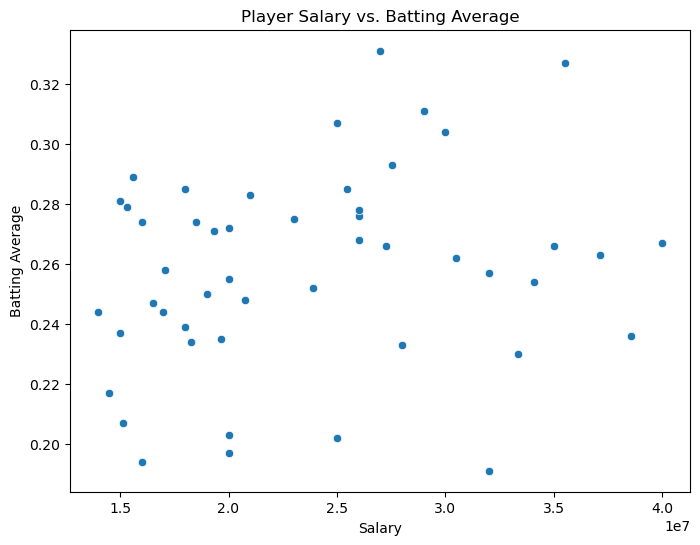

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

# Scatterplot of salary vs batting average
plt.figure(figsize=(8, 6))
sns.scatterplot(x="salary", y="batting_avg", data=combinedmlb_df)
plt.xlabel("Salary")
plt.ylabel("Batting Average")
plt.title("Player Salary vs. Batting Average")
plt.show()

# dots are tending to move up left to right meaning a slight positive correlation
# there is a cluster in the middle where most have a mid rabge salary and mid range batting average

### 2. Histogram

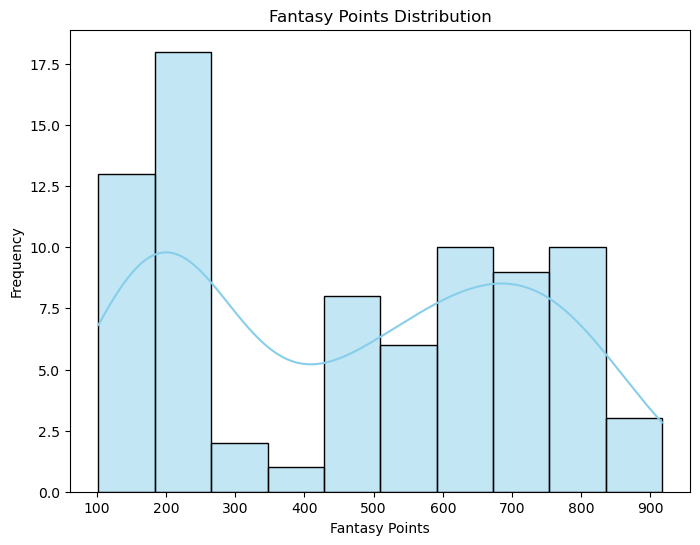

In [59]:
# Fantasy Points data
fantasy_points = combinedmlb_df["FantasyPoints"]

# Create a histogram
plt.figure(figsize=(8, 6))
sns.histplot(fantasy_points, bins=10, kde=True, color='skyblue')
plt.xlabel("Fantasy Points")
plt.ylabel("Frequency")
plt.title("Fantasy Points Distribution")
plt.show()

# Shows how the fantasy points are distributed amongst the players
# largest group has fantasy points between 200-275

### 3. Boxplot

In [60]:
# define the different positions as either hitters or pitchers

hitters_df = combinedmlb_df[combinedmlb_df["Position"].isin(["1B", "2B", "3B", "LF", "RF", "CF", "C", "SS"])]
pitchers_df = combinedmlb_df[combinedmlb_df["Position"].isin(["RP", "DH", "SP"])]

In [61]:
hitters_df["Player_Type"] = "hitter"
pitchers_df["Player_Type"] = "pitcher"

C:\Users\rmtol\AppData\Local\Temp\ipykernel_8680\2611302057.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hitters_df["Player_Type"] = "hitter"
C:\Users\rmtol\AppData\Local\Temp\ipykernel_8680\2611302057.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pitchers_df["Player_Type"] = "pitcher"


In [62]:
# concatenate the hitters and pitchers dataframes

player_type_df = pd.concat([hitters_df, pitchers_df])

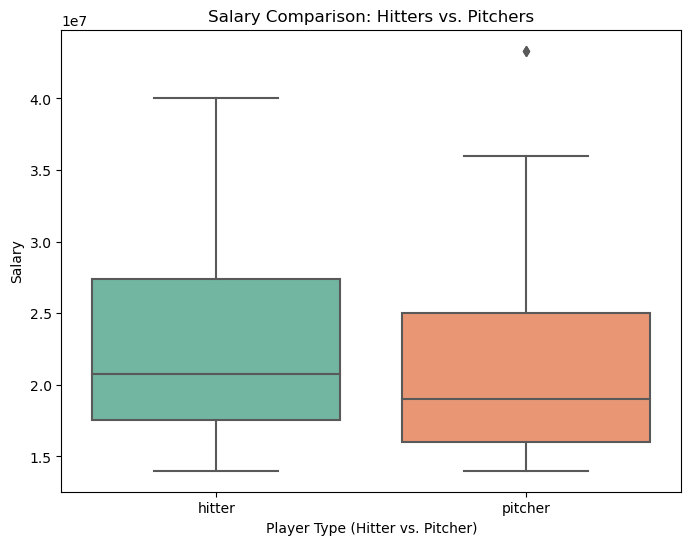

In [63]:
# create a boxplot

plt.figure(figsize=(8, 6))
sns.boxplot(x="Player_Type", y="salary", data=player_type_df, palette="Set2")
plt.xlabel("Player Type (Hitter vs. Pitcher)")
plt.ylabel("Salary")
plt.title("Salary Comparison: Hitters vs. Pitchers")
plt.show()

# Pitchers tend to earn less than hitters

### 4. Violinplots

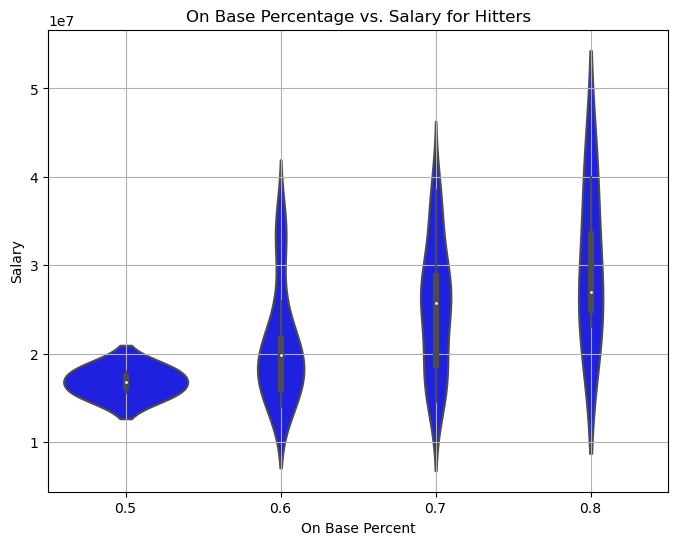

In [64]:
# create a violin plot for hitters

plt.figure(figsize=(8, 6))
sns.violinplot(x="OnBasePercentage", y="salary", data=hitters_df, color="b", alpha=0.6)
plt.xlabel("On Base Percent")
plt.ylabel("Salary")
plt.title("On Base Percentage vs. Salary for Hitters")

plt.grid(True)
plt.show()

# left violin is short showing Players with lower on base percentages have lower salaries
# as the on base percentage increases, the violin gets taller and thinner
# players with the highest on base percentage have the highest salaries
# the white dot is the median salary for hitters in that on base percentage category


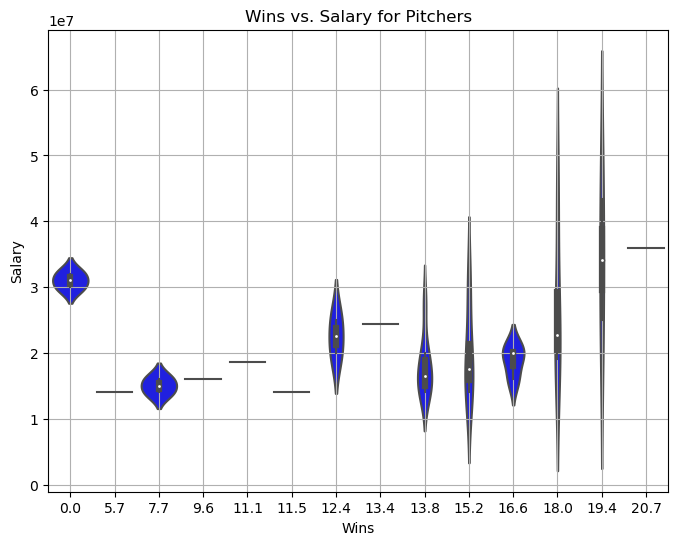

In [65]:
# create a violin plot for pitchers

plt.figure(figsize=(8, 6))
sns.violinplot(x="Wins", y="salary", data=pitchers_df, color="b", alpha=0.6)
plt.xlabel("Wins")
plt.ylabel("Salary")
plt.title("Wins vs. Salary for Pitchers")

plt.grid(True)
plt.show()

# violins tend to get taller and thinner as wins increase
# as pitchers have more wins, their salaries increase
# the white dot is the median salary for pitchers in that win category

### 5. Heatmaps

In [66]:
# calculate the correlation matrix for hitters

h_correlation_matrix = hitters_df[["Singles", "Doubles", "Triples", "HomeRuns", "salary"]].corr()

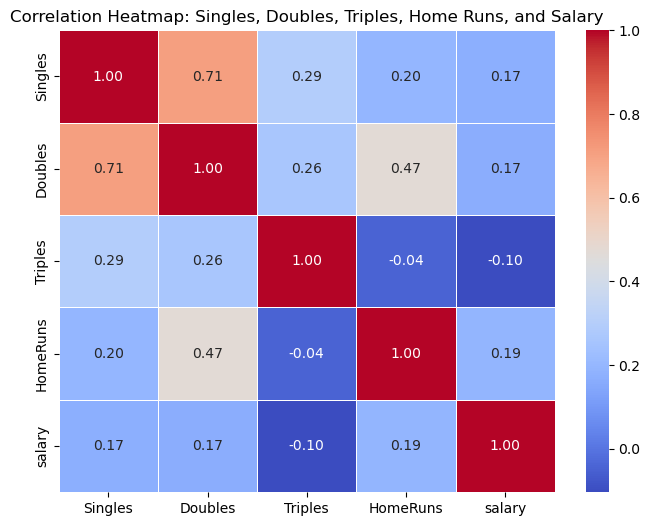

In [67]:
# create a heatmap for hitters' stats and salary
# Hitting doubles has the hightest positive correlation on salary, but all the stats have a  
# positive correlation

plt.figure(figsize=(8, 6))
sns.heatmap(h_correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap: Singles, Doubles, Triples, Home Runs, and Salary")
plt.show()

In [68]:
# calculate the correlation matrix for pitchers

p_correlation_matrix = pitchers_df[["Wins", "Losses", "Saves", "EarnedRunAverage", "salary"]].corr()

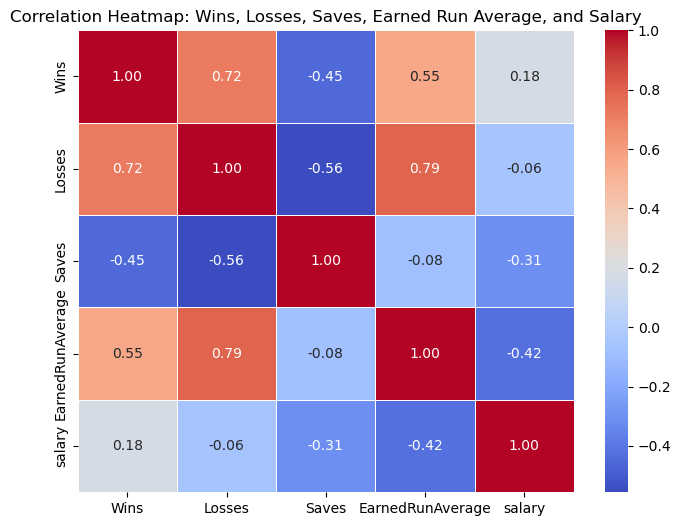

In [69]:
# create a heatmap for pitchers' stats and salary
# Interesting finding that losseshas a positive correlation on salary and saves
# has a negative correlation. 
# As we would expect earned run average which is the number of runs allowed in 9 innings
# has a postive correlation.

plt.figure(figsize=(8, 6))
sns.heatmap(p_correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap: Wins, Losses, Saves, Earned Run Average, and Salary")
plt.show()

## Summary of project and ethical Implications

My project was to collect data on Major League Baseball Batters’ salaries and Pitchers’ salaries and their actual playing stats for the 2023 season. I analyzed trends between the salaries and the stats and then determined whether there is a correlation between game performance and a high salary. Batter stats include figures on Hits, Singles, Doubles, Triples, Homeruns, Batting Average, and Slugging Percent. Pitcher stats include figures on Saves, Outs, Wins, Losses, Earned Run Average, Balls, and Strikes. Finally, I added Fantasy Points as a component to analyze. I felt Fantasy Points would be valuable because the points are calculated by combining the other stats together into one value. Additionally, Fantasy Points paints a clear picture of a player’s overall performance and not just one aspect such as a batter who hits lots of singles but no homeruns. 

I chose two CSV files, one of Pitcher stats and one on Batter stats, which I combined based on the Last Name, First Name field. I did different transformations on the data including changing decimals to percents and looking for duplicates and outliers. 

The Website data I chose was to incorporate Player salaries into my analysis. I combined the salary data from the HTML table into my Player stat file from the CSV to form one file using Last Name, First Name as the common field. One of the transformations I needed to make was to change the name format to match the format from the CSV file. 

The API data I used included some of the same stats as the CSV file, but it also included Fantasy Points. This became important to provide a total score of a Player’s performance based on their hitting or batting stats. I added this data from the API into my other data from the CSV and website again using Last Name, First Name as the common field. Again, one of the transformations I needed to make was to change the name format to match the format from the CSV file. 

For the final piece, I created visualizations from combining the datasets to aid in the analysis. My finding from the Heatmaps regarding the Batters was what I would mostly expect. All the main stats such as Singles, Doubles, Triples and Home Runs have positive correlations on salary with Doubles having the strongest. The Pitchers findings were counterintuitive in that Losses were a positive correlation and Saves were a negative correlation. This could mean that there is less volatility in a Pitcher’s salary (the Boxplot does show that Pitchers earn less overall than Batters), and their position as Pitchers may be more in demand. Additionally, longer Player contracts may show that the salary remains stable over several years while a Pitcher may have an off season. The Violin plots had expected outcomes based upon On Base Percent for Batters and Wins for Pitchers showing that as these figures increased so did salaries. 

There are definitely ethical implications regarding data wrangling in sports that can affect not only Players, but also Fans and Teams. A Player’s confidential information such as their health, their performance stats, and their salaries are made public. A Player should have control over what personal health data is made public. Any mistakes in data accuracy can negatively impact their reputation, their contracts, and ultimately their future in the sport. Also, since fans in Fantasy leagues may place bets based on Fantasy points, inaccurate data could lead to their personal financial losses as well as their engagement in the sport. Lastly API’s publishing real time data that is inaccurate could affect decisions made by coaches such as the lineup or their game strategy. In conclusion a Data Scientist has an ethical responsibility to provide accurate data as this is crucial to the sport as a whole. 
